# Flashpoint Analytics

[Flashpoint Archive](https://flashpointarchive.org/?lang=en-US) is a web-game preservation project, made in 2018 in an effort to save as many games as possible from the then upcoming [Flash End-of-Life](https://www.adobe.com/products/flashplayer/end-of-life-alternative.html), while also making them playable for everyone. Today, it hosts more than 170 000 games and thousands of active users all around the world.

This notebook contains a descriptive statistical analysis about the games available in Flashpoint, with an emphasis on categorical data, such as the technology that was used to make them or the publisher who used to host them in the past.

The Flashpoint database, which keeps all the data that will be used in the analysis, can be found [here](https://web.archive.org/web/20230621043837/https://infinity.unstable.life/Flashpoint/Data/flashpoint.sqlite).

## Import modules

In [1]:
import os
import urllib.request
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

These are the modules that we are going to use for our analysis. Notably:
* *sqlite3* allows us to communicate with a SQLite database;
* *pandas* offers very useful tools for working with data;
* *seaborn* and *matplotlib* come with some handful functions to display and visualize data.

## Retrieve data

In [2]:
try:
    os.mkdir("data")
except FileExistsError:
    pass

# download data from the source (it can take a while)

url = "https://web.archive.org/web/20230621043837id_/https://infinity.unstable.life/Flashpoint/Data/flashpoint.sqlite"
filename = "data/flashpoint.sqlite"
urllib.request.urlretrieve(url, filename)

# connect to the database and store the "game" table in a pandas dataframe

con = sqlite3.connect("data/flashpoint.sqlite")
df = pd.read_sql_query("SELECT * FROM game", con)
con.close()

## Explore data 

Let's have a first look at our data.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177469 entries, 0 to 177468
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   177469 non-null  object 
 1   parentGameId         57600 non-null   object 
 2   title                177469 non-null  object 
 3   alternateTitles      177469 non-null  object 
 4   series               177469 non-null  object 
 5   developer            177469 non-null  object 
 6   publisher            177469 non-null  object 
 7   dateAdded            177469 non-null  object 
 8   dateModified         177469 non-null  object 
 9   platform             177469 non-null  object 
 10  broken               177469 non-null  int64  
 11  extreme              177469 non-null  int64  
 12  playMode             177469 non-null  object 
 13  status               177469 non-null  object 
 14  notes                177469 non-null  object 
 15  source           

There is a total of 27 variables and almost all of them belong to the *object* data type (which is the Pandas equivalent of strings and text), meaning they are categorical. The remaining ones are quantitative instead, either integers or floating-point numbers.

We also notice that most of the variables haven't got any missing data, which is nice.

We are going to need only some of these variables for our goal, so let's keep the relevant ones.

In [4]:
vars_to_keep = ["id", "title", "developer", "publisher", "platform", "releaseDate", "language", "library", "tagsStr"]
df = df[vars_to_keep]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177469 entries, 0 to 177468
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           177469 non-null  object
 1   title        177469 non-null  object
 2   developer    177469 non-null  object
 3   publisher    177469 non-null  object
 4   platform     177469 non-null  object
 5   releaseDate  177469 non-null  object
 6   language     177469 non-null  object
 7   library      177469 non-null  object
 8   tagsStr      177469 non-null  object
dtypes: object(9)
memory usage: 12.2+ MB


To complete our preliminary analysis, let's print the first rows of our dataframe.

In [5]:
df.head()

,id,title,developer,publisher,platform,releaseDate,language,library,tagsStr
0,6db72888-6aa5-34c9-0ff3-ffe4cfe0fc61,All Grown Up: Krazy Karts,Ezone,Nickelodeon,3D Groove GX,,,arcade,Racing
1,3bba3af6-8e76-b2c8-b423-2d2d8bdfdd50,Showdown: The Gunfighting Game,3D Groove,3D Groove,3D Groove GX,,,arcade,Shooter
2,fb479276-2325-4dbb-bafd-64fcc8aeb684,Hamsterball Bowling,Ezone,atv.Disney.go.com,3D Groove GX,,,arcade,Arcade
3,7cdff5f4-11cb-b1de-51bc-bca13ef78adb,Dunk Tank,Ezone,atv.Disney.go.com,3D Groove GX,,,arcade,Arcade
4,1d9ff021-2404-9785-bb7d-0fceda67a55d,Baby Knight,Pepworks,Pepworks,3D Groove GX,,,arcade,Platformer


Here comes a bad news: some values in our dataset are empty strings, meaning that *de facto* they are actually missing, though formally there are no null values.

## Analyze data 

### Developers and Publishers

We may be interested to know who are the most prolific developers and publishers. Let's find out by creating a frequency table for each variable and looking at the first ten entries.

In [6]:
top_developers = df["developer"].value_counts()[:10]
top_developers

developer
                   46151
123Bee              2730
Games2Rule          2441
Games2Jolly.com     1915
Selfdefiant         1603
WowEscape.com       1436
Top10NewGames       1144
PalmarianFire       1059
Ena Game Studio     1031
Neopets              957
Name: count, dtype: int64

The first row is blank because of the issue we noticed earlier: some games do not have a developer value associated to them in the database. Let's filter out those entries.

In [7]:
top_developers = df.loc[df.developer != '', "developer"].value_counts()[:10]
top_developers

developer
123Bee             2730
Games2Rule         2441
Games2Jolly.com    1915
Selfdefiant        1603
WowEscape.com      1436
Top10NewGames      1144
PalmarianFire      1059
Ena Game Studio    1031
Neopets             957
Mirchi Games        812
Name: count, dtype: int64

These are the most represented developers in the database. As a Flash games fan may notice at first glance, most of them are specialised in escape games; therefore, we can suppose that it should be a very popular genre: we will dig into this later.

Before moving on, Neopets deserves a special mention for how it managed to build a passionate community still active after over 25 years since its release in 1999.

In [8]:
top_publishers = df.loc[df.publisher != '', "publisher"].value_counts()[:10]
top_publishers

publisher
DeviantArt         7655
Newgrounds         6550
Disney             2428
Nickelodeon        1659
Armor Games        1437
GameMonetize       1374
Eka's Portal       1261
Cartoon Network    1243
Kongregate         1219
Melting-Mindz      1214
Name: count, dtype: int64

Among the publishers, we can see some very renowned names, at least in the gaming community, like *Newgrounds*, *Armor Games* and *Kongregate*. There is also a considerable amount of licensed games published by TV broadcasters, such as *Disney*, *Nickelodeon* and *Cartoon Network*, supposedly to promote their shows.

The main publishing platform is DeviantArt, which, despite being known mostly as a place for artists to store their drawings, also offers the possibility to share Flash content.

Now let's look at a visualization of the same data, by making use of bar plots and pie charts.

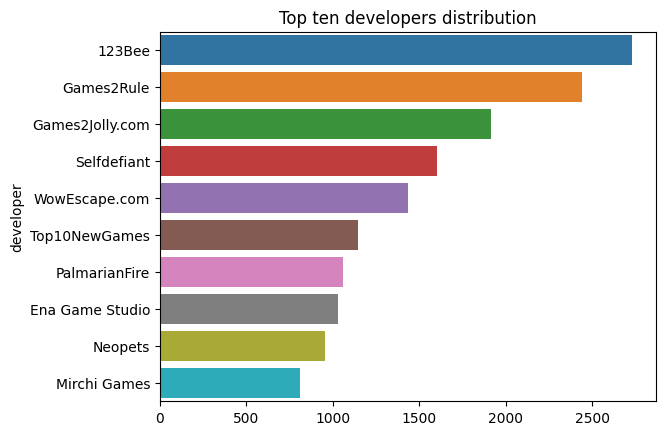

In [9]:
sns.barplot(x = top_developers.values, y = top_developers.index, orient = "h").set(title = "Top ten developers distribution");

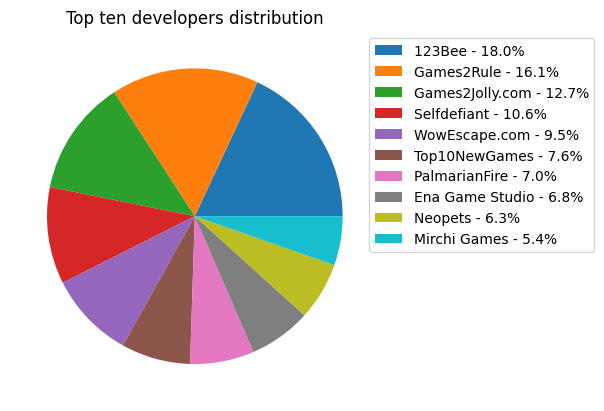

In [10]:
labels = top_developers.index
sizes = top_developers.values / top_developers.values.sum() * 100
plt.pie(sizes, textprops = {"color":"w"})
labels = [f"{l} - {s:0.1f}%" for l, s in zip(labels, sizes)]
plt.legend(labels = labels, bbox_to_anchor = (1.6,1), loc = "best")
plt.title("Top ten developers distribution")
plt.show()

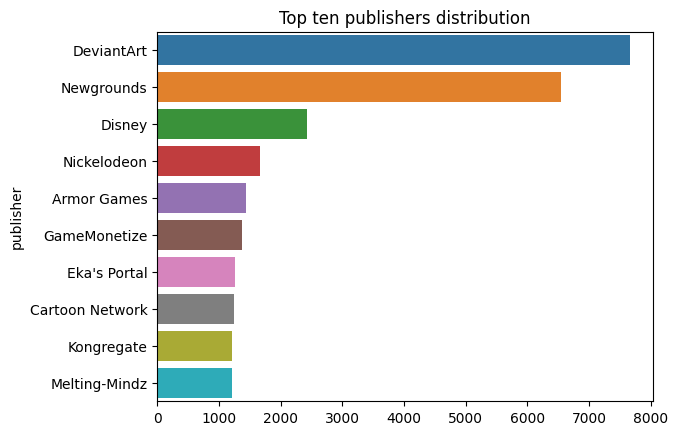

In [11]:
sns.barplot(x = top_publishers.values, y = top_publishers.index, orient = "h").set(title = "Top ten publishers distribution");

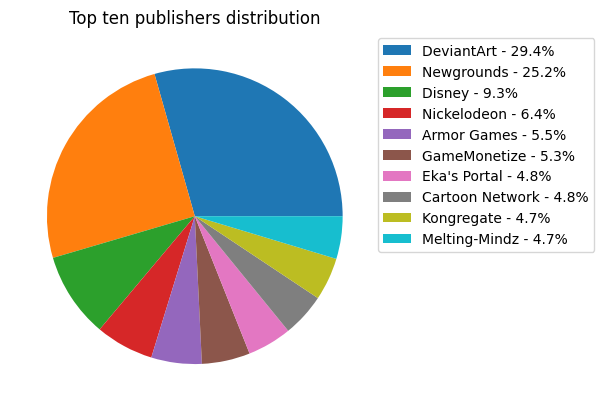

In [12]:
labels = top_publishers.index
sizes = top_publishers.values / top_publishers.values.sum() * 100
plt.pie(sizes, textprops = {"color":"w"})
labels = [f"{l} - {s:0.1f}%" for l, s in zip(labels, sizes)]
plt.legend(labels = labels, bbox_to_anchor = (1.6,1), loc = "best")
plt.title("Top ten publishers distribution")
plt.show()

### Release Dates and Platforms

Flash games started to appear towards the end of the twentieth century and became popular in the next decade, before slowly fading out in favour of mobile games.

Let's observe the release dates we have got here, keeping in mind that they are not specified for all games.

In [13]:
df_dates = df.loc[(df.releaseDate != ""), ["title", "releaseDate", "platform", "library"]].sort_values(by=["releaseDate"])
df_dates

,title,releaseDate,platform,library
26897,TankTrouble,16-12-2007,Flash,arcade
47769,Blastar,1984,HTML5,arcade
141921,Idle Johnny,1993,Shockwave,theatre
155542,ZZZ...I want to sleep,1994,Shockwave,theatre
155541,The Health Checkup,1994,Shockwave,theatre
...,...,...,...,...
37388,GWL Hayley Footjob (Commission),2080-10-05,Flash,arcade
50821,Havok Xtra Marble Demo,21/08/2001,Shockwave,arcade
50893,Ray Cast Car,27/06/2001,Shockwave,arcade
105547,(Gift) Luna's Christmas gift,2917-12-26,Flash,theatre


There seems to be a problem with the data: entries should follow the "YYYY-MM-DD" date format as per Flashpoint guidelines, but some games come with a different one; in addition, if the exact day or month of release is unknown, specifying the year only is also allowed.

Let's clean up our data for consistency.

In [14]:
warnings.filterwarnings("ignore", category = UserWarning)
df_dates["releaseDate"] = pd.to_datetime(df_dates["releaseDate"], format="mixed", errors="coerce")
df_dates = df_dates.dropna().sort_values("releaseDate")
df_dates

,title,releaseDate,platform,library
47769,Blastar,1984-01-01,HTML5,arcade
141921,Idle Johnny,1993-01-01,Shockwave,theatre
155542,ZZZ...I want to sleep,1994-01-01,Shockwave,theatre
155541,The Health Checkup,1994-01-01,Shockwave,theatre
141942,QP-Shot 1000,1994-01-01,Shockwave,arcade
...,...,...,...,...
175851,Awesome Game,2022-12-23,HTML5,arcade
175933,Christmas in Vienna,2022-12-23,HTML5,arcade
175934,Chrysler Building,2022-12-23,HTML5,arcade
177404,"T-Mobile Tuesdays: Win $2,300 for 2023!",2022-12-27,HTML5,arcade


As explained in the [documentation](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html), the *mixed* value for the *format* parameter forces Pandas to infer the format of each date one by one, while the *coerce* value sets any non-parseable dates to the NaT value, which we later dropped.

*Pandas* automatically assigns January 1 as month and day for those games for which only the year of release is known.
There is still one odd observation, the last one, which is most likely a typo.

In [15]:
df_dates = df_dates[:-1]
df_dates[:20]

,title,releaseDate,platform,library
47769,Blastar,1984-01-01,HTML5,arcade
141921,Idle Johnny,1993-01-01,Shockwave,theatre
155542,ZZZ...I want to sleep,1994-01-01,Shockwave,theatre
155541,The Health Checkup,1994-01-01,Shockwave,theatre
141942,QP-Shot 1000,1994-01-01,Shockwave,arcade
155545,Dangerous Two,1994-01-01,Shockwave,theatre
73010,Virtual Banana Original,1994-02-01,VRML,arcade
134268,Virtual University of Auckland,1994-02-01,Hyper-G,arcade
102651,Clock Tower,1994-11-17,VRML,arcade
134765,The Austrian National Library,1994-11-17,VRML,arcade


Finally, we have got our correct release dates. We see that the oldest game in the list is *Blastar*, which was released in 1984. Actually, the game present in Flashpoint is a HTML5 version, which was developed and released much more recently.

Moving on, starting from 1993 we recognize some old technologies, such as *Shochwave*, *VRML* and *Hyper-G*.

We can actually distinguish between proper games and animations by looking at the *library* column: the former are labeled with *arcade*, the latter with *theatre* values. Thus, the oldest animation featured is *Idle Johnny* from 1993, while the first "true" game (not counting *Blastar*) could be either *QP-Shot 1000* (which came out some time in 1994), or *Virtual Banana Original* and *Virtual University of Auckland*, both from February 1st, 1994.

In [16]:
df_dates = df_dates[1:]
df_dates[-20:]

,title,releaseDate,platform,library
175058,Um Conto da Cloe,2022-12-08,HTML5,arcade
176260,Pad of Time,2022-12-08,HTML5,arcade
175153,/f/ 101,2022-12-09,Flash,arcade
176537,Vault of the Pineapples,2022-12-09,HTML5,arcade
172001,Snowsgiving Choose Your Own Adventure,2022-12-10,HTML5,arcade
177431,look_into_my_eyes_its_open_wide.swf,2022-12-10,Flash,theatre
176112,In the Name of Freedom: Black Apocalypse,2022-12-13,HTML5,arcade
175448,Mcdonalds Final,2022-12-13,HTML5,arcade
172414,The Smurfs Cooking,2022-12-13,HTML5,arcade
172155,Cartoon Network Winter Games,2022-12-14,HTML5,arcade


On the other side, here are the 20 most recent games. As expected, we find out that nowadays *HTML5* is the standard technology to make browser games, though some exceptions occur and there are even a couple of *Flash* entries!

For the sake of completeness, let's restrict our search to *Flash*-only games.

In [17]:
df_dates.loc[(df_dates.platform == "Flash")][:20]

,title,releaseDate,platform,library
175939,Claus.com,1995-01-01,Flash,arcade
165097,Artcore,1996-01-01,Flash,arcade
123757,The Simpsons 1996 website normal version,1996-01-01,Flash,arcade
104886,The Hole in the Wall website intro,1996-01-01,Flash,theatre
104785,Animated Screen Beans,1996-01-01,Flash,theatre
105332,Past*Present*Future,1996-01-01,Flash,theatre
97904,2 Design's Navigational Demo,1996-01-01,Flash,arcade
98020,The Silicon Slip,1996-01-01,Flash,arcade
97944,Good Music Company Website,1996-01-01,Flash,arcade
99690,"Simple, Tasty Buttons",1996-01-01,Flash,arcade


The first *Flash* game is *Claus.com* from 1995. We notice from the titles that most of these are actually websites built in *Flash* and not individual games or animations.

To take an overall view, let's compare the various platforms by games count, considering the top five.

In [18]:
top_platforms = df_dates["platform"].value_counts()[:5]
top_platforms

platform
Flash        59047
HTML5        10904
Shockwave     1999
Unity          875
Java           751
Name: count, dtype: int64

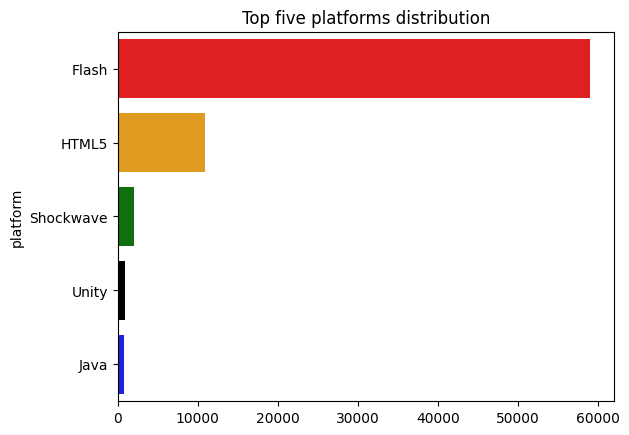

In [19]:
colors = ["red", "orange", "green", "black", "blue"]
sns.barplot(x = top_platforms.values, y = top_platforms.index, orient = "h", palette = colors).set(title = "Top five platforms distribution");

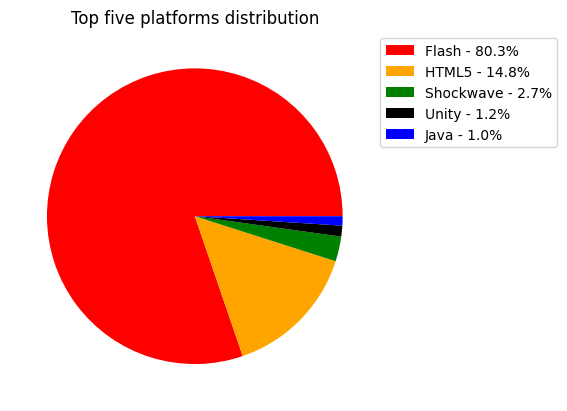

In [20]:
labels = top_platforms.index
sizes = top_platforms.values / top_platforms.values.sum() * 100
plt.pie(sizes, colors = colors, textprops = {"color":"w"})
labels = [f"{l} - {s:0.1f}%" for l, s in zip(labels, sizes)]
plt.legend(labels = labels, bbox_to_anchor = (1.5,1), loc = "best")
plt.title("Top five platforms distribution")
plt.show()

*Flash* is clearly the winner, followed by a rising *HTML5* and its old companion *Shockwave*, with *Unity* and *Java* as outsiders.

Web games were at their peak in the 2000s and many gamers are nostalgic about that decade, which could be considered a golden age. Thus, we expect to see that most of the games in our database have been released between 2000 and 2009. Let's check it out, while also comparing technologies against years.

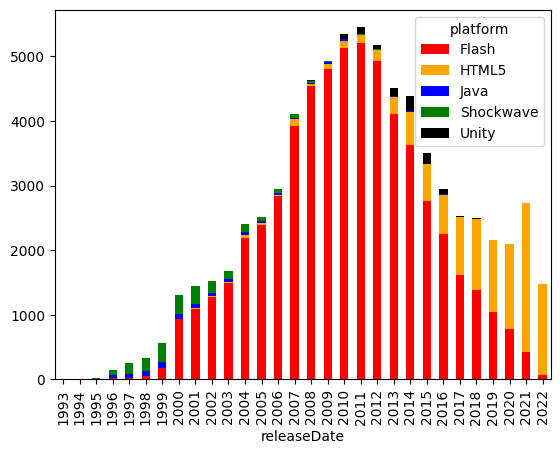

In [21]:
df_year_platform = df_dates.loc[(df_dates["platform"].isin(top_platforms.index)), :].copy()
years = df_year_platform["releaseDate"].astype(str).str[:4]
df_year_platform[df_year_platform.columns[1]] = years.values
df_year_platform.groupby(["releaseDate", "platform"]).size().unstack().plot(kind = 'bar', stacked = True, color = ["red", "orange", "blue", "green", "black"]);

As we were expecting, web games have steadily risen in popularity in the first decade of the third millennium, reached a peak in 2011 and today their number is slowly decreasing, apart from some fluctuations. This does not necessarily imply that fewer games are being made: it could simply be that there is less incentive to curate and preserve a recent game written in a technology which will probably stay on for a long time compared to an old game with a nostalgic value that is at risk of disappearing at any time.

*Flash* dominated the scene between 2000 and 2017 (it's impressive to see that it lasted so long), while *HTML5* started to be relevant around 2013. *Shockwave* was most popular between 1996 and 2000, but continued to be used until 2007. *Unity* had six years of relative notoriety (2010-2016) and lastly, Java, despite being one of the first technologies eligible for making web games, has never known much use and moved off the radar around 2010.

## Most common languages

Let's move on to another topic: *Flashpoint* allows non-English content as well, and it can be interesting to know which countries have contributed the most to the world of web games aside from the anglophone ones.

In [22]:
top_languages = df.loc[df["language"] != "", "language"].str.replace(",", ";").str.split("; ").explode().value_counts().drop("en")[:10]
top_languages

language
ja    7709
pt    3350
es    3095
ko    2525
fr    2519
de    2298
pl    2183
ru    2015
zh    2011
it    1612
Name: count, dtype: int64

A game can come in different languages: in the dataset, this information is conveyed by listing the language codes separated by a colon and a space (e.g. "en; it"). Therefore, we had to count each occurrence individually by using the *explode* method.

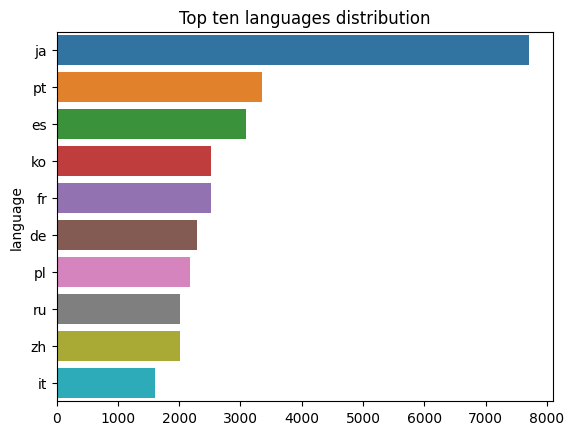

In [23]:
sns.barplot(x = top_languages.values, y = top_languages.index, orient = "h").set(title = "Top ten languages distribution");

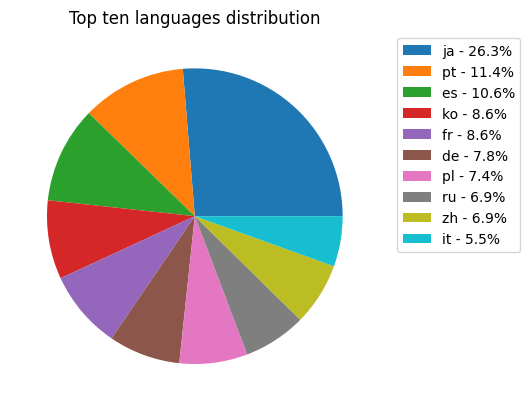

In [24]:
labels = top_languages.index
sizes = top_languages.values / top_languages.values.sum() * 100
plt.pie(sizes, textprops = {"color":"w"})
labels = [f"{l} - {s:0.1f}%" for l, s in zip(labels, sizes)]
plt.legend(labels = labels, bbox_to_anchor = (1.4,1), loc = "best")
plt.title("Top ten languages distribution")
plt.show()

We can see a strong presence of Asian content, with Japanese, Korean and Chinese among the top ten languages. The rest of the list is completed by European countries, namely Portugal, Spain, France, Germany, Poland and Italy, as well as Russia.

## Most popular genres

Let's now focus on game genres, featured on the *tagsStr* column, to discover the most common ones. For games with multiple genres, the same convention used for the languages applies.

In [25]:
top_genres = df.loc[df["tagsStr"] != "", "tagsStr"].str.replace(",", ";").str.split("; ").explode().value_counts()[:10]
top_genres

tagsStr
Arcade             27308
Puzzle             25284
Adventure          24981
Escape the Room    17725
Dress Up           12101
Simulation         11993
Action             10452
Score-Attack        9703
Loop                7599
Mouse-only          7232
Name: count, dtype: int64

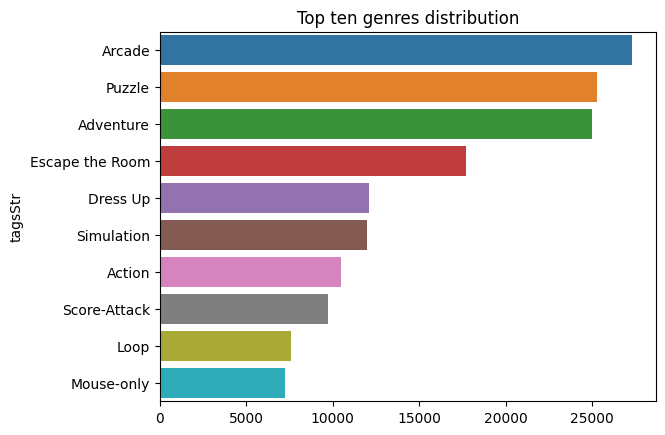

In [26]:
sns.barplot(x = top_genres.values, y = top_genres.index, orient = "h").set(title = "Top ten genres distribution");

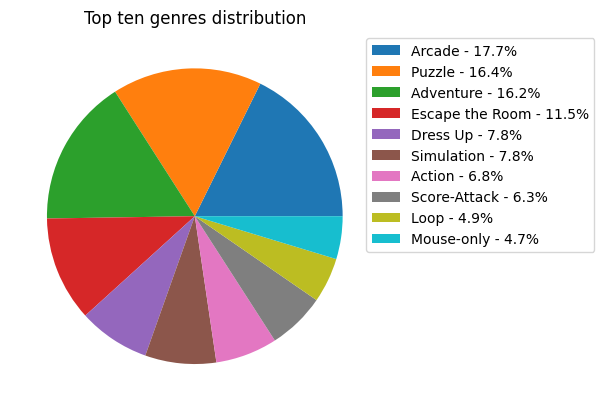

In [27]:
labels = top_genres.index
sizes = top_genres.values / top_genres.values.sum() * 100
plt.pie(sizes, textprops = {"color":"w"})
labels = [f"{l} - {s:0.1f}%" for l, s in zip(labels, sizes)]
plt.legend(labels = labels, bbox_to_anchor = (1.6,1), loc = "best")
plt.title("Top ten genres distribution")
plt.show()

The big three genres are *Arcade*, *Puzzle* and *Adventure* and honestly it's kind of odd to see *Action* at such a low position. Conversely, as we expected from our previous analysis on developers, *Escape the Room* is fairly popular, along with *Dress Up* and *Simulation* games.

## Most played games

As a final insight, let's find out which are the most played games among the *Flashpoint* users: to do this, we are going to use some official statistics from the platform itself. Visit [this webpage](https://web.archive.org/web/20230622070602/https://flashpoint-analytics.unstable.life/), scroll down to the corresponding section and download the data in *.csv* format.

In [28]:
most_played = pd.read_csv("data/most_played.csv")
most_played.rename(columns = {"category": "id"}, inplace = True)
most_played

,id,Play Count
0,83e1b5e7-4282-4bbd-868e-dcfa965e4abf,56574
1,a94d865c-cb38-4d31-96f3-dda26502c4a3,12194
2,617ca7f3-1cff-3f0c-5b53-07498b3b28d8,9224
3,8d09fc0d-6f25-4be6-b396-8fcaddad4e5e,8667
4,b0ce771e-7c02-4317-8528-ba48139e2688,8627
5,fdee4800-b5c9-49e0-b19e-22f2b0ccab68,8349
6,1e903a30-5c37-15bb-8e5e-6fea5a8103f2,8042
7,b9a8dbb9-0cd7-434b-b226-13dc9dd07b49,7724
8,07921a2f-26fd-4364-9671-ee0c8d256ec1,7605
9,92ba2d91-e041-2bd4-49ea-21758df711ff,7151


The file contains the *id* for the most 40 played games, along with a play count. Let's use the identifiers to find the titles of these games and other info by merging the main dataframe and the new data.

In [29]:
df_rank = df.merge(most_played, on = "id").sort_values("Play Count", ascending = False).reset_index()
df_rank

,index,id,title,developer,publisher,platform,releaseDate,language,library,tagsStr,Play Count
0,39,83e1b5e7-4282-4bbd-868e-dcfa965e4abf,Poptropica,Sandbox Networks Inc.; Pearson Education,,Flash,2007-09,en,arcade,Educational; Platformer; Puzzle; Variety; Side...,56574
1,33,a94d865c-cb38-4d31-96f3-dda26502c4a3,Jacksmith,Flipline Studios,PapaLouie.com,Flash,2012-09-27,en,arcade,Simulation; Time Management,12194
2,26,617ca7f3-1cff-3f0c-5b53-07498b3b28d8,Papa's Cheeseria,Flipline Studios,PapaLouie.com,Flash,2015-06-10,en,arcade,Cooking; Simulation; Time Management; Achievem...,9224
3,18,8d09fc0d-6f25-4be6-b396-8fcaddad4e5e,Strike Force Heroes 3,Sky9 Games,Armor Games,Flash,,en,arcade,Action; Shooter,8667
4,1,b0ce771e-7c02-4317-8528-ba48139e2688,Super Mario Bros. Crossover,Exploding Rabbit,,Flash,2010-04-27,en,arcade,Arcade; Platformer; Score-Attack; Pixel; Side-...,8627
5,35,fdee4800-b5c9-49e0-b19e-22f2b0ccab68,Strike Force Heroes,Sky9 Games,Armor Games,Flash,2012-05-31,en,arcade,Shooter; Action,8349
6,3,1e903a30-5c37-15bb-8e5e-6fea5a8103f2,Papa's Scooperia,Flipline Studios,PapaLouie.com,Flash,2018-07-24,en,arcade,Cooking; Simulation; Time Management; Achievem...,8042
7,30,b9a8dbb9-0cd7-434b-b226-13dc9dd07b49,Papa's Sushiria,Flipline Studios,PapaLouie.com,Flash,2016-12-13,en,arcade,Cooking; Simulation; Time Management; Achievem...,7724
8,22,07921a2f-26fd-4364-9671-ee0c8d256ec1,Bloons TD 5,Ninja Kiwi,Ninja Kiwi,Flash,2011-12-13,en,arcade,Tower Defense; Strategy,7605
9,4,92ba2d91-e041-2bd4-49ea-21758df711ff,Papa's Freezeria,Flipline Studios,Armor Games,Flash,2011-08-05,en,arcade,Cooking; Simulation; Time Management; Achievem...,7151


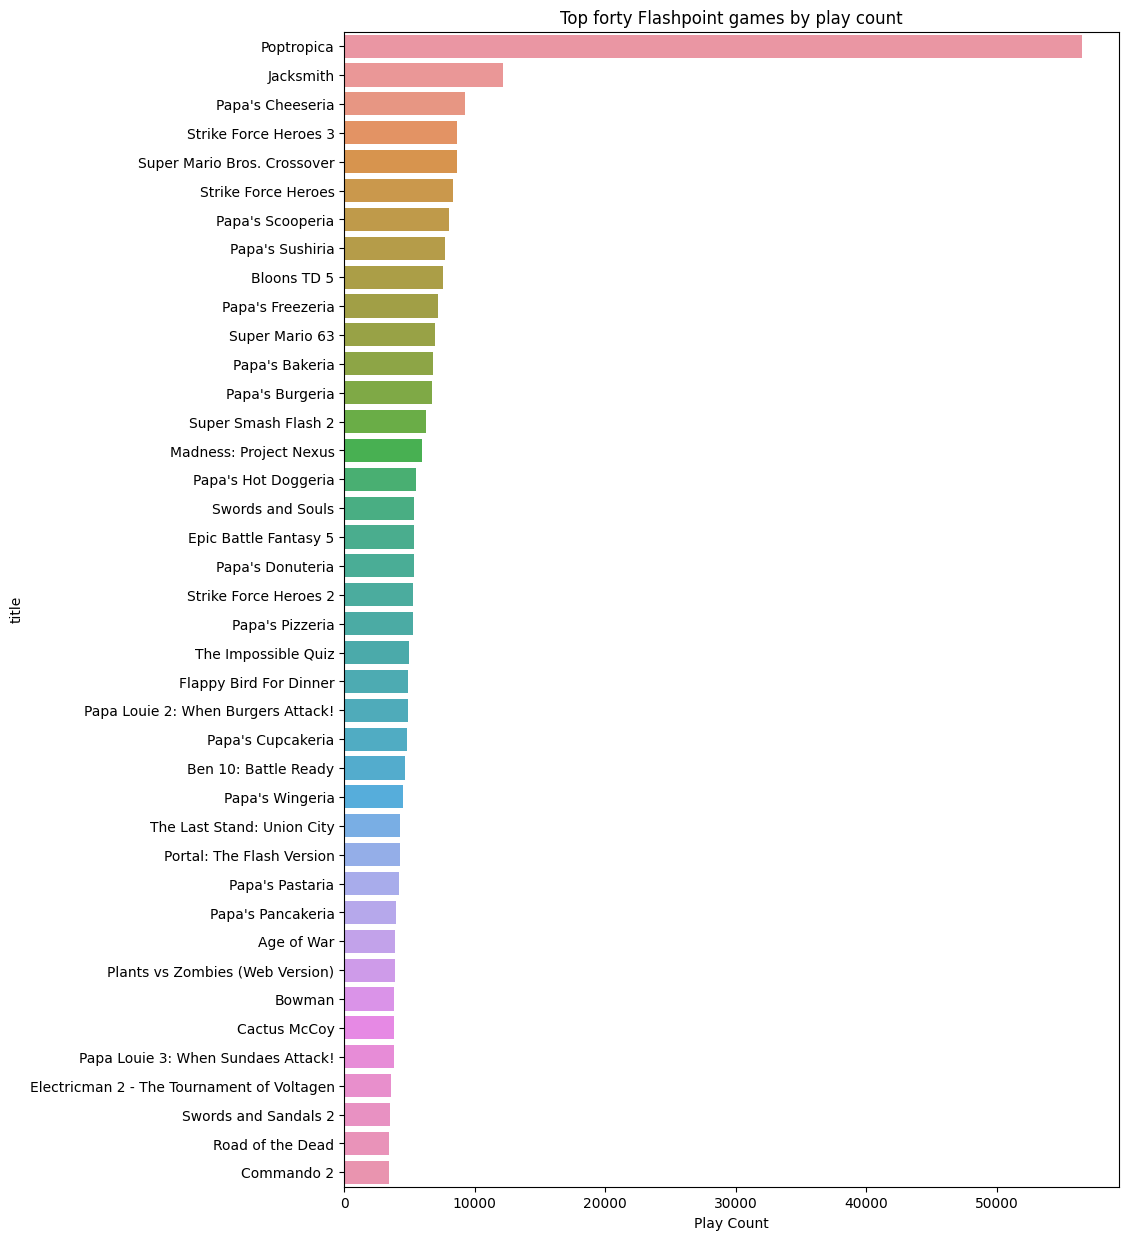

In [30]:
fig, ax = plt.subplots(figsize=(10, 15))
sns.barplot(x = df_rank["Play Count"][:40], y = df_rank["title"][:40], orient = "h", ax = ax).set(title = "Top forty Flashpoint games by play count");

*Poptropica* is the indisputable winner, with over fifty thousand play counts. There is a massive presence of *Papa's Gameria* franchise, as well as all-time classics like *Strike Force Heroes*, *Super Mario 63* and *Age of War*. Finally, a special remark about *Ben 10: Battle Ready*, which was thought to be lost forever, before it was restored and made playable again on *Flashpoint*.

## Conclusion

This was a thorough analysis of the *Flashpoint* catalogue, which hopefully gives some insights about the world of web-based games and their significant relevance in the history of the Internet.

The effort to preserve this kind of content has generated amazing results, saving an astounding quantity of material which would have disappeared otherwise. Despite the concrete risk of a digital dark age, we should insist on preserving the stuff that we care about and keep it alive, not only for historical reasons, but also for the nostalgic value we associate with it.